# **Ames Housing Price Prediction - Exploratory Data Analysis**

## Objective

This notebook performs exploratory data analysis on the Ames Housing dataset
to understand the characteristics of the data, identify important predictors,
investigate missing values, detect anomalies, and guide preprocessing decisions
before building machine learning models.

In [1]:
#Define library
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [3]:

import pandas as pd

train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
print("Dataset Shape:", train.shape)

Dataset Shape: (1460, 81)


In [ ]:
#info
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
for col in train.columns:
    print("=" * 80)
    print(f"Column: {col}")

    value_counts = train[col].value_counts(dropna=False)

    if train[col].nunique() <= 30:
        values_horizontal = " | ".join(
            [f"{str(index)}:{count}" for index, count in value_counts.items()]
        )
        print(values_horizontal)
    else:
        print(f"Too many unique values: {train[col].nunique()}")

    print()

Column: Id
Too many unique values: 1460

Column: MSSubClass
20:536 | 60:299 | 50:144 | 120:87 | 30:69 | 160:63 | 70:60 | 80:58 | 90:52 | 190:30 | 85:20 | 75:16 | 45:12 | 180:10 | 40:4

Column: MSZoning
RL:1151 | RM:218 | FV:65 | RH:16 | C (all):10

Column: LotFrontage
Too many unique values: 110

Column: LotArea
Too many unique values: 1073

Column: Street
Pave:1454 | Grvl:6

Column: Alley
nan:1369 | Grvl:50 | Pave:41

Column: LotShape
Reg:925 | IR1:484 | IR2:41 | IR3:10

Column: LandContour
Lvl:1311 | Bnk:63 | HLS:50 | Low:36

Column: Utilities
AllPub:1459 | NoSeWa:1

Column: LotConfig
Inside:1052 | Corner:263 | CulDSac:94 | FR2:47 | FR3:4

Column: LandSlope
Gtl:1382 | Mod:65 | Sev:13

Column: Neighborhood
NAmes:225 | CollgCr:150 | OldTown:113 | Edwards:100 | Somerst:86 | Gilbert:79 | NridgHt:77 | Sawyer:74 | NWAmes:73 | SawyerW:59 | BrkSide:58 | Crawfor:51 | Mitchel:49 | NoRidge:41 | Timber:38 | IDOTRR:37 | ClearCr:28 | SWISU:25 | StoneBr:25 | Blmngtn:17 | MeadowV:17 | BrDale:16 | Ve

In [ ]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [ ]:
print("Duplicates:", train.duplicated().sum())

Duplicates: 0


### **Histogram for target variable (sales price)**

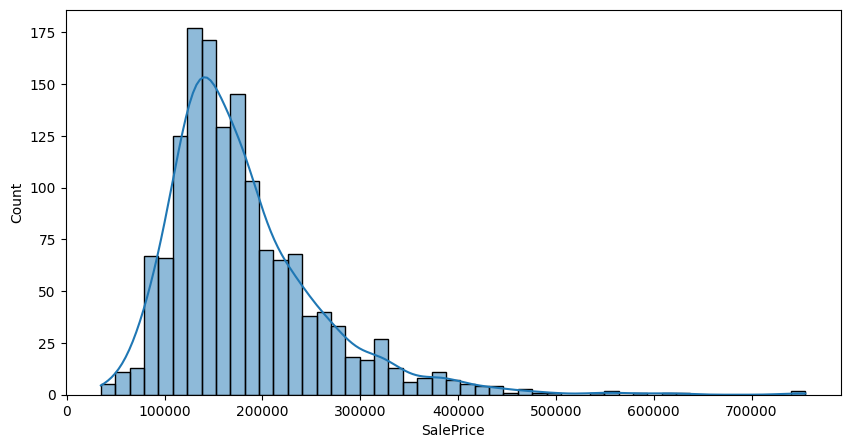

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    train["SalePrice"],
    kde=True
)

plt.show()

We need to check if the price greater than 500000 are outliner or not

In [ ]:
train.loc[train["SalePrice"] > 500000]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
178,179,20,RL,63.0,17423,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,New,Partial,501837
440,441,20,RL,105.0,15431,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,555000
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000
769,770,60,RL,47.0,53504,Pave,NaN,IR2,HLS,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,538000
803,804,60,RL,107.0,13891,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2009,New,Partial,582933
898,899,20,RL,100.0,12919,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2010,New,Partial,611657
1046,1047,60,RL,85.0,16056,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2006,New,Partial,556581
1169,1170,60,RL,118.0,35760,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2006,WD,Normal,625000
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,...,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000


In [ ]:
high_price = train[train["SalePrice"] > 500000]

high_price[
    [
        "SalePrice",
        "OverallQual",
        "GrLivArea",
        "YearBuilt",
        "Neighborhood",
        "GarageCars",
        "GarageArea",
        "TotalBsmtSF"
    ]
]

,SalePrice,OverallQual,GrLivArea,YearBuilt,Neighborhood,GarageCars,GarageArea,TotalBsmtSF
178,501837,9,2234,2008,StoneBr,3,1166,2216
440,555000,10,2402,2008,NridgHt,3,672,3094
691,755000,10,4316,1994,NoRidge,3,832,2444
769,538000,8,3279,2003,StoneBr,3,841,1650
803,582933,9,2822,2008,NridgHt,3,1020,1734
898,611657,9,2364,2009,NridgHt,3,820,2330
1046,556581,9,2868,2005,StoneBr,3,716,1992
1169,625000,10,3627,1995,NoRidge,3,807,1930
1182,745000,10,4476,1996,NoRidge,3,813,2396


The houseprice >= 500000 are not actually outlinears as they match the above features

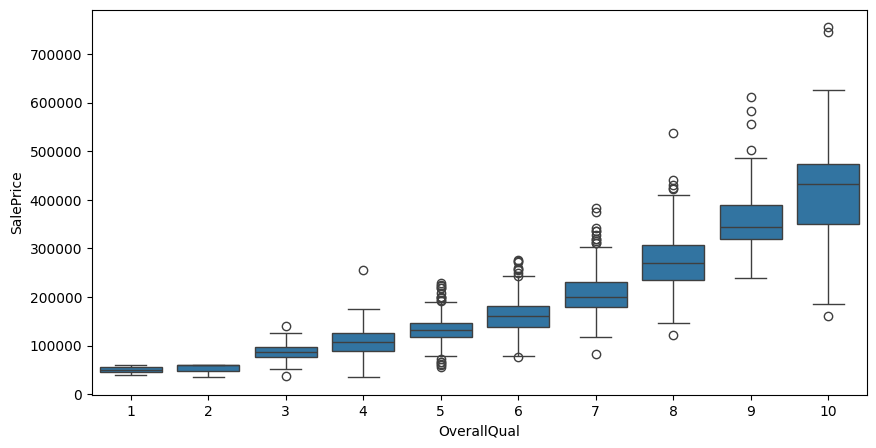

In [ ]:
#OverallQual vs SalePrice
plt.figure(figsize=(10,5))

sns.boxplot(
    data=train,
    x="OverallQual",
    y="SalePrice"
)

plt.show()

OverallQual is one of the strongest predictors of SalePrice because it summarizes many aspects of house quality. The model should include this feature, while considering its non-linear relationship with price.

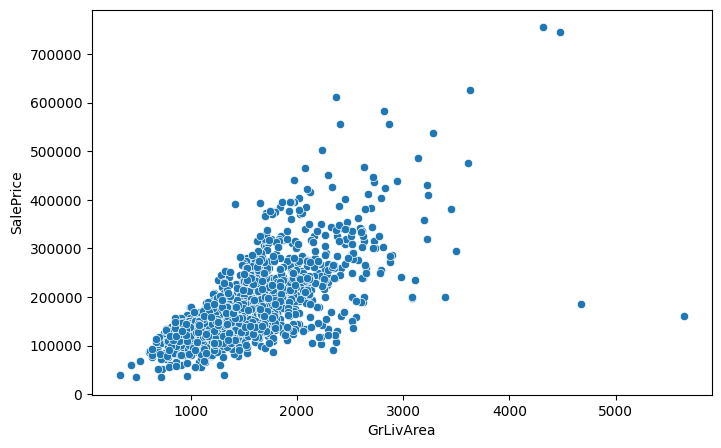

In [ ]:
#GrLivArea vs SalePrice
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=train,
    x="GrLivArea",
    y="SalePrice"
)

plt.show()

In [ ]:
#investgate the unusall
train[
    train["GrLivArea"] > 4500
][
    [
        "SalePrice",
        "GrLivArea",
        "OverallQual",
        "Neighborhood",
        "YearBuilt"
    ]
]

,SalePrice,GrLivArea,OverallQual,Neighborhood,YearBuilt
523,184750,4676,10,Edwards,2007
1298,160000,5642,10,Edwards,2008


In [ ]:
outliers = train[
    (train["GrLivArea"] > 4500) &
    (train["SalePrice"] < 300000)
]

outliers.index

Index([523, 1298], dtype='int64')

Two extreme observations with unusually large living areas (>4500 sq ft) but disproportionately low sale prices were identified. These observations are known anomalies in the Ames Housing dataset and were removed to prevent distortion of regression models.

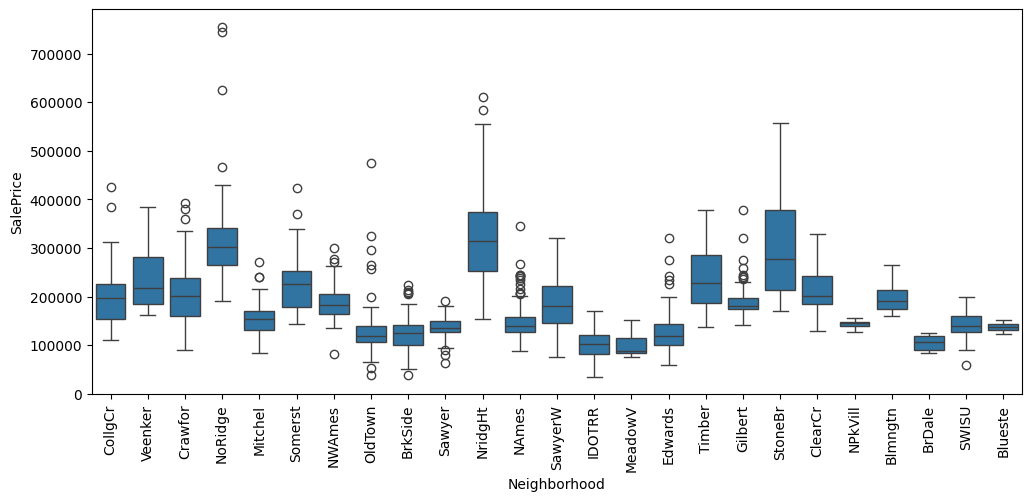

In [ ]:
plt.figure(figsize=(12,5))

sns.boxplot(
    data=train,
    x="Neighborhood",
    y="SalePrice"
)

plt.xticks(rotation=90)

plt.show()

Neighborhood is an important feature for predicting SalePrice because different neighborhoods show distinct price levels and distributions. The model should include this feature, with categorical encoding methods such as One-Hot Encoding.

### **Correlation analysis**

In [ ]:
corr = train.select_dtypes(include="number").corr()

corr["SalePrice"].sort_values(ascending=False)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


### **Heatmap**

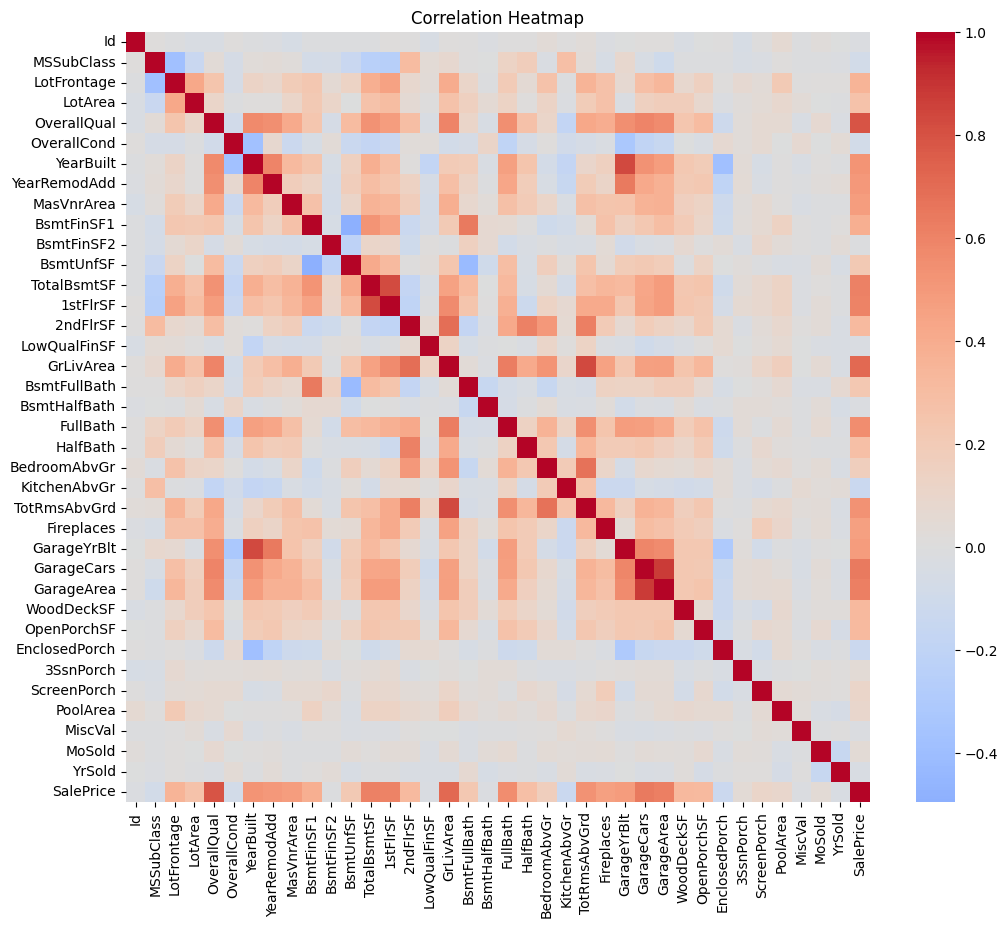

In [ ]:
plt.figure(figsize=(12,10))

sns.heatmap(
    train.select_dtypes(include="number").corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

Correlation analysis shows that house quality, living area, basement size, and garage-related features have the strongest linear relationships with SalePrice. OverallQual is the most influential numerical feature, followed by GrLivArea and TotalBsmtSF. However, categorical variables such as Neighborhood should also be considered because they capture location-based differences that correlation analysis cannot measure.

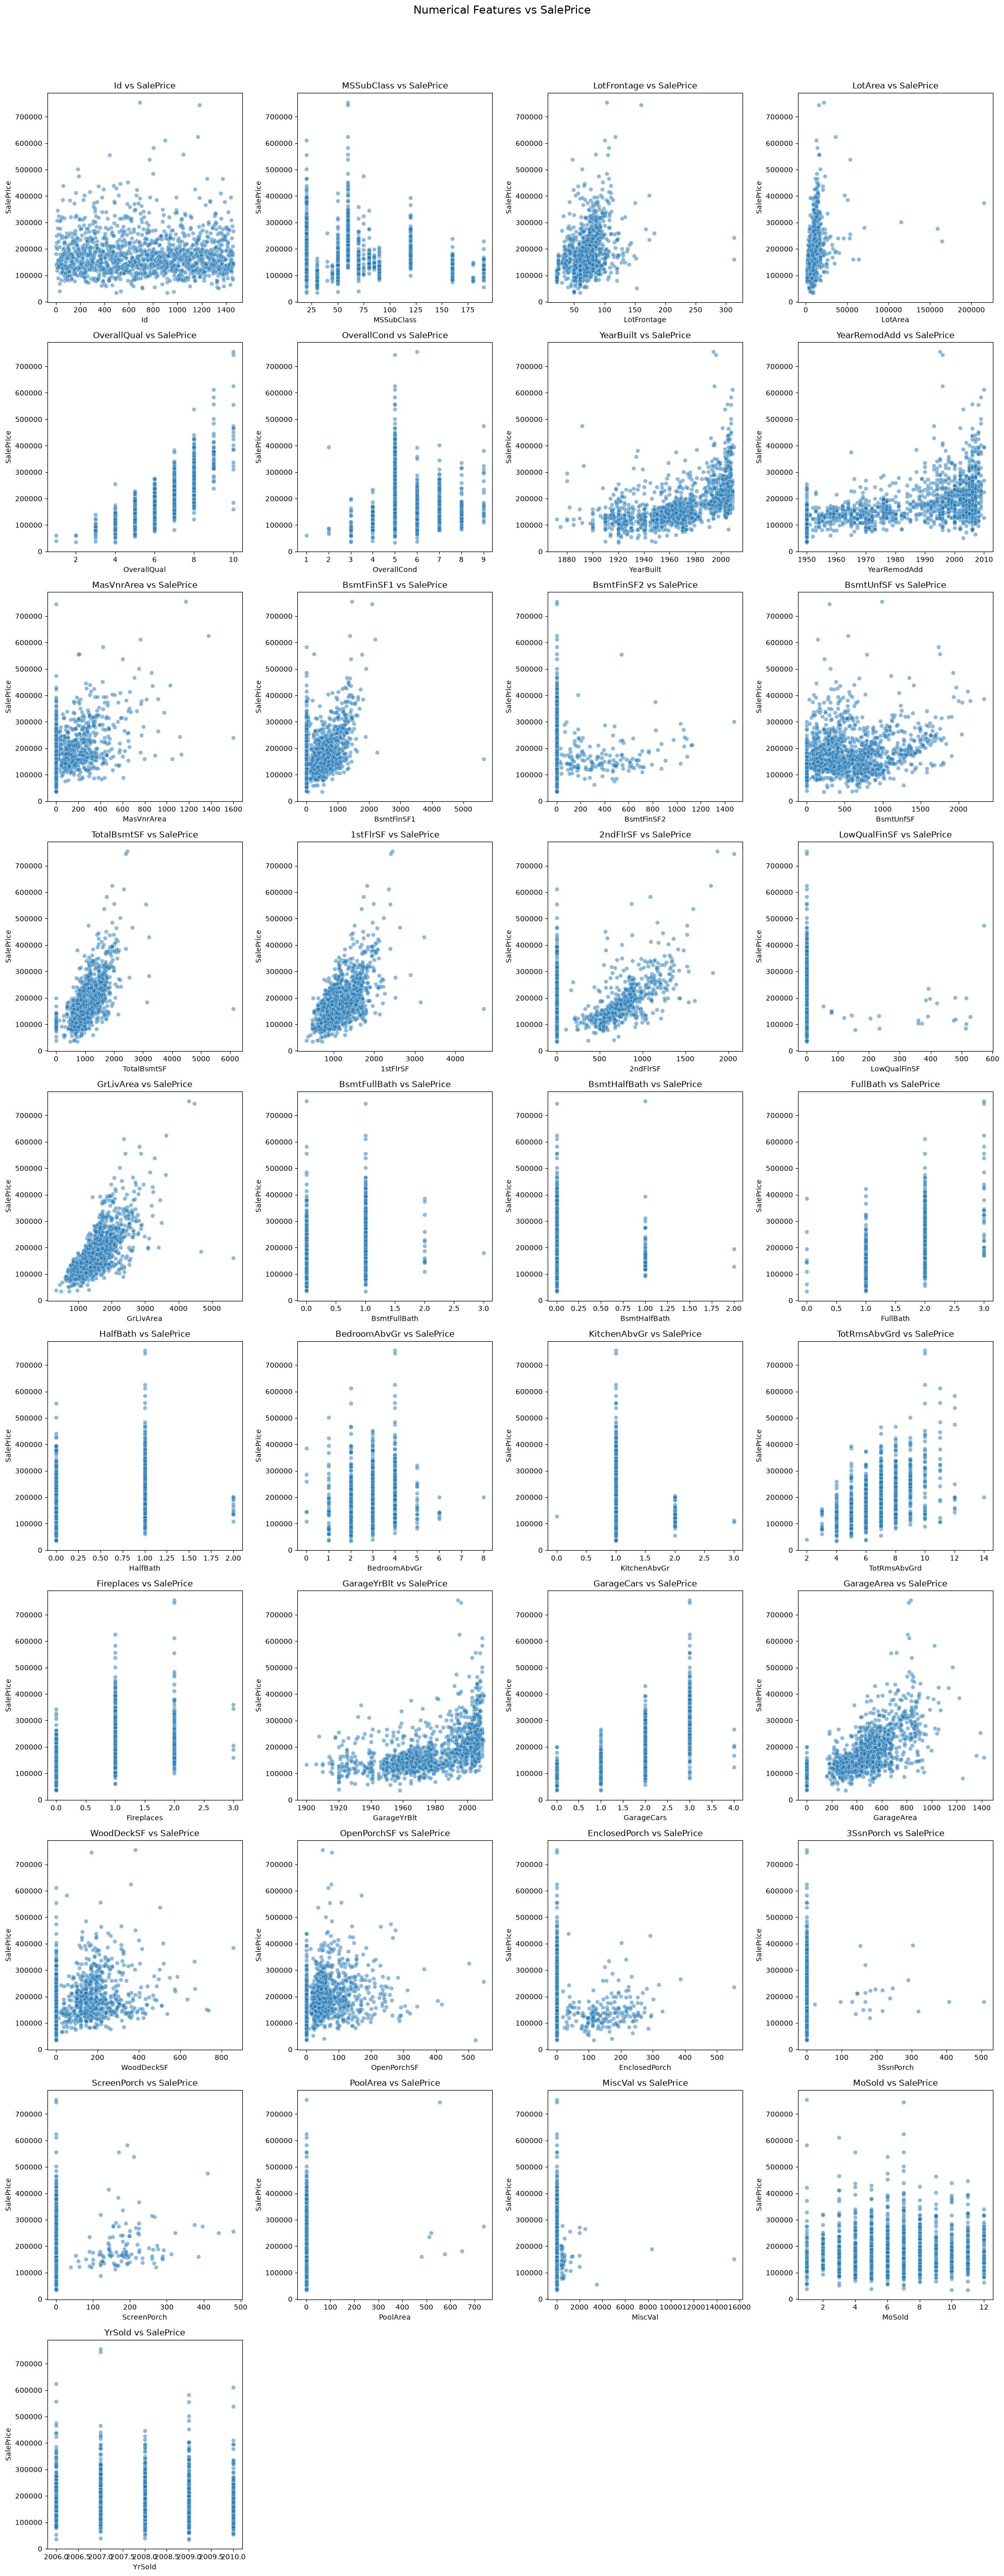

In [ ]:
# Select numerical features except target
numeric_features = (
    train.select_dtypes(include=np.number)
    .columns
    .drop("SalePrice")
)

# Number of columns and rows
cols = 4
rows = int(np.ceil(len(numeric_features) / cols))

# Create subplot grid
fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(20, rows * 5)
)

# Flatten axes for easy iteration
axes = axes.flatten()

# Plot every numerical feature against SalePrice
for i, feature in enumerate(numeric_features):

    sns.scatterplot(
        data=train,
        x=feature,
        y="SalePrice",
        ax=axes[i],
        alpha=0.5
    )

    axes[i].set_title(
        f"{feature} vs SalePrice"
    )

    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("SalePrice")


# Remove empty plots
for j in range(i + 1, len(axes)):
    axes[j].remove()


plt.suptitle(
    "Numerical Features vs SalePrice",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

**Missing value**

In [ ]:
missing = train.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing_percent = (missing / len(train) * 100).round(2)

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent
})

missing_df

,Missing Values,Percentage
PoolQC,1452,99.59
MiscFeature,1404,96.30
Alley,1367,93.76
Fence,1177,80.73
MasVnrType,872,59.81
FireplaceQu,690,47.33
LotFrontage,259,17.76
GarageType,81,5.56
GarageYrBlt,81,5.56
GarageFinish,81,5.56


In [ ]:
missing_cols = train.columns[train.isnull().any()]

for col in missing_cols:
    print(
        col,
        "| Type:",
        train[col].dtype,
        "| Missing:",
        train[col].isnull().sum()
    )

LotFrontage | Type: float64 | Missing: 259
Alley | Type: object | Missing: 1367
MasVnrType | Type: object | Missing: 872
MasVnrArea | Type: float64 | Missing: 8
BsmtQual | Type: object | Missing: 37
BsmtCond | Type: object | Missing: 37
BsmtExposure | Type: object | Missing: 38
BsmtFinType1 | Type: object | Missing: 37
BsmtFinType2 | Type: object | Missing: 38
Electrical | Type: object | Missing: 1
FireplaceQu | Type: object | Missing: 690
GarageType | Type: object | Missing: 81
GarageYrBlt | Type: float64 | Missing: 81
GarageFinish | Type: object | Missing: 81
GarageQual | Type: object | Missing: 81
GarageCond | Type: object | Missing: 81
PoolQC | Type: object | Missing: 1452
Fence | Type: object | Missing: 1177
MiscFeature | Type: object | Missing: 1404


In [4]:
from src.visualization import plot_saleprice_distribution

plot_saleprice_distribution(train)

WindowsPath('C:/Users/dania/OneDrive/Desktop/house-price-prediction/outputs/figures/saleprice_distribution.png')

# Summary of EDA Findings

The exploratory data analysis revealed several important characteristics of the Ames Housing dataset.

- SalePrice exhibits a positively skewed distribution with a small number of high-value properties.
- OverallQual is the strongest numerical predictor of house prices.
- GrLivArea has a strong positive relationship with SalePrice.
- Neighborhood significantly influences housing prices.
- Several features contain missing values that require preprocessing before model training.
- Two anomalous observations with unusually large living areas were identified and will be removed during preprocessing.
- These findings will guide the preprocessing, feature engineering, and model development stages.

## Handling Missing Values

Missing values were handled based on the meaning of each feature rather than applying a single filling strategy to all columns. In the Ames Housing dataset, some missing values do not represent unknown information; instead, they indicate that a particular house feature does not exist.

### 1. Categorical Features

For categorical variables where missing values represent the absence of a property feature, missing values were replaced with **"None"**.

Examples:

- **Alley**: A missing value indicates that the house does not have alley access.
- **MasVnrType**: A missing value indicates that the house has no masonry veneer.
- **Basement features** (`BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2`): Missing values indicate that the house does not have a basement.
- **Garage features** (`GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`): Missing values indicate that the house does not have a garage.
- **FireplaceQu**: Missing values indicate that the house does not contain a fireplace.
- **PoolQC**: Missing values indicate that the house does not have a pool.
- **Fence**: Missing values indicate that the property does not have a fence.
- **MiscFeature**: Missing values indicate that no additional miscellaneous feature exists.

Replacing these values with "None" preserves the information that the feature is absent instead of treating it as missing unknown data.

---

### 2. Numerical Features

Numerical missing values were handled differently depending on the feature meaning.

- **LotFrontage**:
  - Contains 259 missing values.
  - Missing values were replaced using the median value of the column.
  - The median was selected because it is less affected by extreme property sizes and outliers compared to the mean.

- **MasVnrArea**:
  - Missing values were replaced with `0`.
  - This represents houses without masonry veneer area.

- **GarageYrBlt**:
  - Missing values were replaced with `0`.
  - This represents houses that do not have a garage.

---

### 3. Single Missing Categorical Value

- **Electrical**:
  - Only one missing value was present.
  - It was replaced using the most frequent category (mode) because the missing value was likely due to data recording issues rather than absence of the feature.

---

### Summary

The missing-value treatment was based on domain understanding of the housing dataset:

- Missing categorical values representing absent features → replaced with `"None"`.
- Missing numerical values representing absence → replaced with `0`.
- Numerical variables with unknown values → replaced using the median.
- A single missing categorical value → replaced using the most common category.

This approach preserves important information from missing values and prepares the dataset for machine learning modeling.